In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("준비 완료!")

준비 완료!


In [5]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# 12개 변수 모두 적용
features = df.columns.drop('quality').tolist()
print("사용할 변수:", features)
print("변수 개수:", len(features))

X = df[features]
y = df['quality']

# 훈련 80% / 테스트 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("훈련 데이터:", len(X_train))
print("테스트 데이터:", len(X_test))

사용할 변수: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
변수 개수: 11
훈련 데이터: 1279
테스트 데이터: 320


In [6]:
# 랜덤포레스트 모델 만들기
rf_model = RandomForestRegressor(
    n_estimators=100,  # 결정 트리 100개 사용
    random_state=42
)

# 훈련 데이터로 학습
rf_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred_rf = rf_model.predict(X_test)

# 성능 평가
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("=== 랜덤포레스트 결과 ===")
print(f"R²:   {r2_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")

print("\n=== 다중회귀 vs 랜덤포레스트 비교 ===")
print(f"4개 변수 랜덤포레스트 R²: 0.470  RMSE: 0.589")
print(f"11개 변수 랜덤포레스트 R²: {r2_rf:.3f}  RMSE: {rmse_rf:.3f}")
print(f"랜덤포레스트 R²: {r2_rf:.3f}  RMSE: {rmse_rf:.3f}")

=== 랜덤포레스트 결과 ===
R²:   0.539
RMSE: 0.549

=== 다중회귀 vs 랜덤포레스트 비교 ===
4개 변수 랜덤포레스트 R²: 0.470  RMSE: 0.589
11개 변수 랜덤포레스트 R²: 0.539  RMSE: 0.549
랜덤포레스트 R²: 0.539  RMSE: 0.549


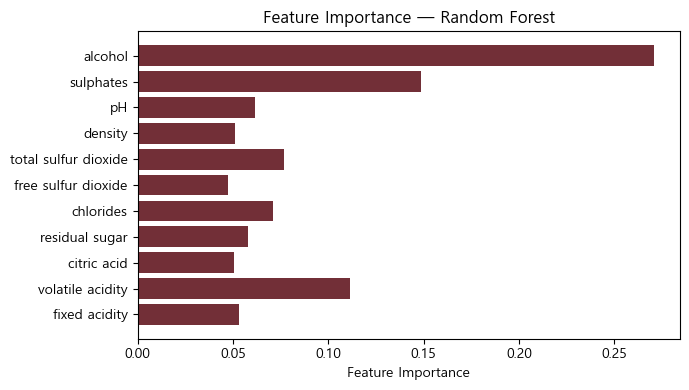

fixed acidity       : 0.053
volatile acidity    : 0.112
citric acid         : 0.051
residual sugar      : 0.058
chlorides           : 0.071
free sulfur dioxide : 0.047
total sulfur dioxide: 0.077
density             : 0.051
pH                  : 0.061
sulphates           : 0.148
alcohol             : 0.271


In [7]:
# 랜덤포레스트는 각 변수가 얼마나 중요한지 알려줘요
importances = rf_model.feature_importances_

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(features, importances, color='#722F37')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

for feature, imp in zip(features, importances):
    print(f"{feature:20s}: {imp:.3f}")

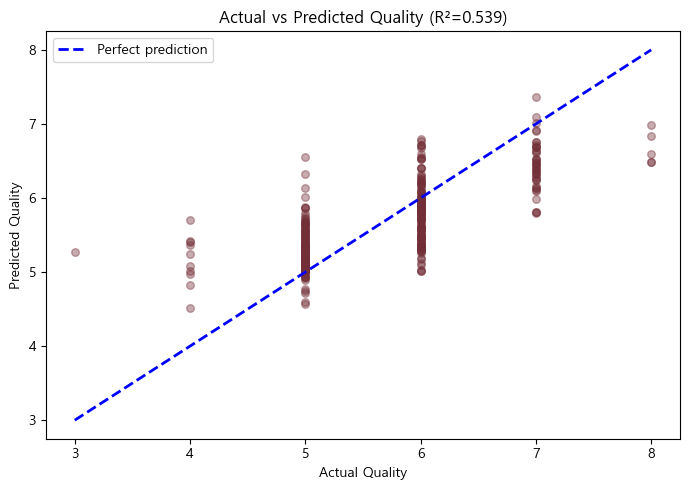

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y_test, y_pred_rf, color='#722F37', s=30, alpha=0.4)
ax.plot([3, 8], [3, 8], color='blue', linewidth=2,
        linestyle='--', label='Perfect prediction')

ax.set_xlabel('Actual Quality')
ax.set_ylabel('Predicted Quality')
ax.set_title(f'Actual vs Predicted Quality (R²={r2_rf:.3f})')
ax.legend()

plt.tight_layout()
plt.show()

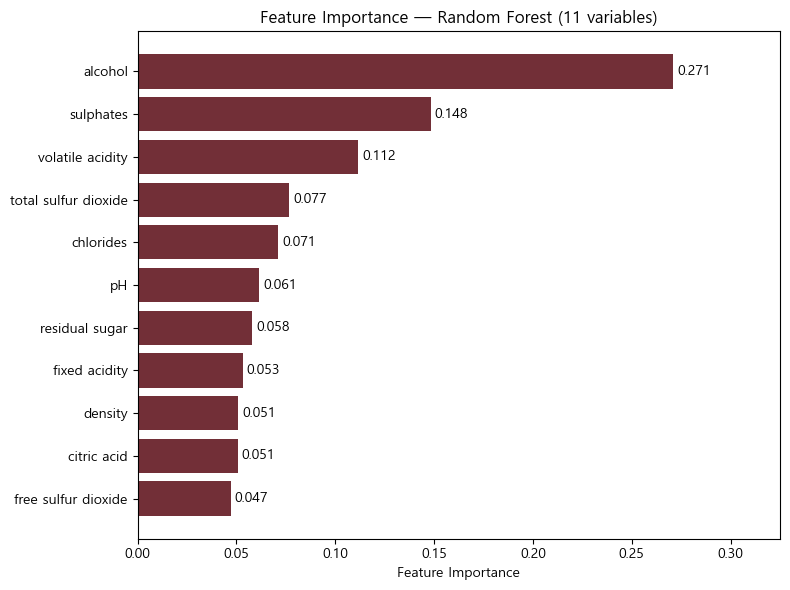

In [11]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['feature'], importance_df['importance'],
        color='#722F37')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance — Random Forest (11 variables)')

# 막대 끝에 숫자 표시
for i, (val, name) in enumerate(zip(importance_df['importance'],
                                     importance_df['feature'])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center')

# x축 범위 늘려서 숫자가 잘리지 않게
ax.set_xlim(0, max(importance_df['importance']) * 1.2)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()